# Marginalization & Substance Use Correlation

Analysis of the relationship between perceived discrimination/marginalization and substance use among students.

In [1]:
import sys
sys.path.insert(0, '../scripts')
from helpers import *
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline

# Load data
df = load_survey_data()
df = clean_survey_data(df)

print(f"Loaded {len(df)} survey responses")
print(f"\nColumns: {df.columns.tolist()}")

Loaded 366 survey responses

Columns: ['timestamp', 'age', 'grade/class', 'gender', 'average_hours_spent_studying_per_day', 'preferred_study_method', 'subject(s)_you_find_most_challenging', 'extra-curricular_activities_you_participate_in', 'do_you_feel_marginalized_or_discriminated_against_at_school/college/university?', 'have_you_ever_used_tobacco,_alcohol,_or_other_substances?']


In [2]:
# Find the marginalization and substance columns
margin_col = [col for col in df.columns if 'marginalized' in col.lower()][0]
substance_col = [col for col in df.columns if 'tobacco' in col.lower() or 'substance' in col.lower()][0]

print(f"Marginalization column: {margin_col}")
print(f"Substance column: {substance_col}")

# Create cross-tabulation
crosstab = pd.crosstab(df[margin_col], df[substance_col], margins=True)
print("\nCross-tabulation:")
print(crosstab)

# Calculate percentages within each marginalization group
crosstab_pct = pd.crosstab(df[margin_col], df[substance_col], normalize='index') * 100
print("\nPercentages (by marginalization group):")
print(crosstab_pct.round(1))

Marginalization column: do_you_feel_marginalized_or_discriminated_against_at_school/college/university?
Substance column: have_you_ever_used_tobacco,_alcohol,_or_other_substances?

Cross-tabulation:
have_you_ever_used_tobacco,_alcohol,_or_other_substances?  No  Sometimes  Yes  \
do_you_feel_marginalized_or_discriminated_again...                              
Never                                                       9          0   47   
Often                                                       6          1   52   
Rarely                                                      4          2  108   
Sometimes                                                  17          0  120   
All                                                        36          3  327   

have_you_ever_used_tobacco,_alcohol,_or_other_substances?  All  
do_you_feel_marginalized_or_discriminated_again...              
Never                                                       56  
Often                                 

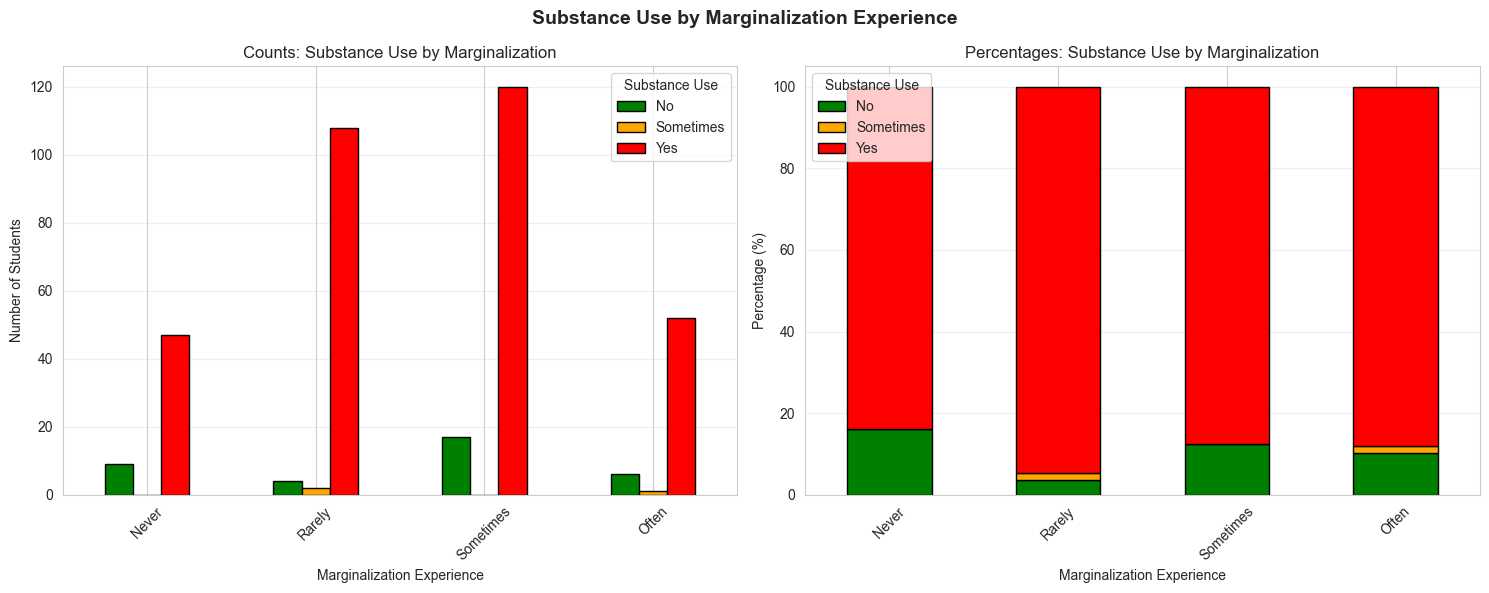

✓ Chart saved: visuals/04_marginalization_substance_correlation.png


In [3]:
# Create visualization 1: Grouped bar chart
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Substance Use by Marginalization Experience', fontsize=14, fontweight='bold')

# Order marginalization from Never to Often
order = ['Never', 'Rarely', 'Sometimes', 'Often']

# Prepare data
crosstab_data = pd.crosstab(df[margin_col], df[substance_col])
crosstab_data = crosstab_data.reindex(order, fill_value=0)

# Grouped bar chart (counts)
crosstab_data.plot(kind='bar', ax=axes[0], color=['green', 'orange', 'red'], edgecolor='black')
axes[0].set_xlabel('Marginalization Experience')
axes[0].set_ylabel('Number of Students')
axes[0].set_title('Counts: Substance Use by Marginalization')
axes[0].legend(title='Substance Use', labels=['No', 'Sometimes', 'Yes'])
axes[0].grid(alpha=0.3, axis='y')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)

# Stacked percentage bar chart
crosstab_pct = crosstab_data.div(crosstab_data.sum(axis=1), axis=0) * 100
crosstab_pct.plot(kind='bar', stacked=True, ax=axes[1], color=['green', 'orange', 'red'], edgecolor='black')
axes[1].set_xlabel('Marginalization Experience')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_title('Percentages: Substance Use by Marginalization')
axes[1].legend(title='Substance Use', labels=['No', 'Sometimes', 'Yes'], loc='upper left')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../visuals/04_marginalization_substance_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Chart saved: visuals/04_marginalization_substance_correlation.png")

In [4]:
# Statistical analysis
from scipy.stats import chi2_contingency

# Chi-square test
contingency_table = pd.crosstab(df[margin_col], df[substance_col])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("="*60)
print("STATISTICAL ANALYSIS: Marginalization vs Substance Use")
print("="*60)
print(f"\nChi-square Test:")
print(f"  χ² statistic: {chi2:.4f}")
print(f"  p-value: {p_value:.4f}")
print(f"  Degrees of freedom: {dof}")

if p_value < 0.05:
    print(f"\n  ✓ SIGNIFICANT correlation (p < 0.05)")
    print(f"    Marginalization and substance use are statistically associated.")
else:
    print(f"\n  ✗ No significant correlation (p ≥ 0.05)")
    print(f"    No strong statistical association detected.")

# Detailed breakdown
print("\n" + "="*60)
print("DETAILED BREAKDOWN BY MARGINALIZATION STATUS")
print("="*60)

for status in order:
    subset = df[df[margin_col] == status]
    n = len(subset)
    
    # Substance use counts
    substance_counts = subset[substance_col].value_counts()
    no_use = substance_counts.get('No', 0)
    sometimes = substance_counts.get('Sometimes', 0)
    yes_use = substance_counts.get('Yes', 0)
    
    # Calculate "any use"
    any_use = sometimes + yes_use
    any_use_pct = (any_use / n * 100) if n > 0 else 0
    
    print(f"\n{status.upper()} (n={n}):")
    print(f"  No substance use: {no_use} ({no_use/n*100:.1f}%)")
    print(f"  Sometimes: {sometimes} ({sometimes/n*100:.1f}%)")
    print(f"  Yes (regular): {yes_use} ({yes_use/n*100:.1f}%)")
    print(f"  → ANY substance involvement: {any_use} ({any_use_pct:.1f}%)")

STATISTICAL ANALYSIS: Marginalization vs Substance Use

Chi-square Test:
  χ² statistic: 11.7423
  p-value: 0.0680
  Degrees of freedom: 6

  ✗ No significant correlation (p ≥ 0.05)
    No strong statistical association detected.

DETAILED BREAKDOWN BY MARGINALIZATION STATUS

NEVER (n=56):
  No substance use: 9 (16.1%)
  Sometimes: 0 (0.0%)
  Yes (regular): 47 (83.9%)
  → ANY substance involvement: 47 (83.9%)

RARELY (n=114):
  No substance use: 4 (3.5%)
  Sometimes: 2 (1.8%)
  Yes (regular): 108 (94.7%)
  → ANY substance involvement: 110 (96.5%)

SOMETIMES (n=137):
  No substance use: 17 (12.4%)
  Sometimes: 0 (0.0%)
  Yes (regular): 120 (87.6%)
  → ANY substance involvement: 120 (87.6%)

OFTEN (n=59):
  No substance use: 6 (10.2%)
  Sometimes: 1 (1.7%)
  Yes (regular): 52 (88.1%)
  → ANY substance involvement: 53 (89.8%)


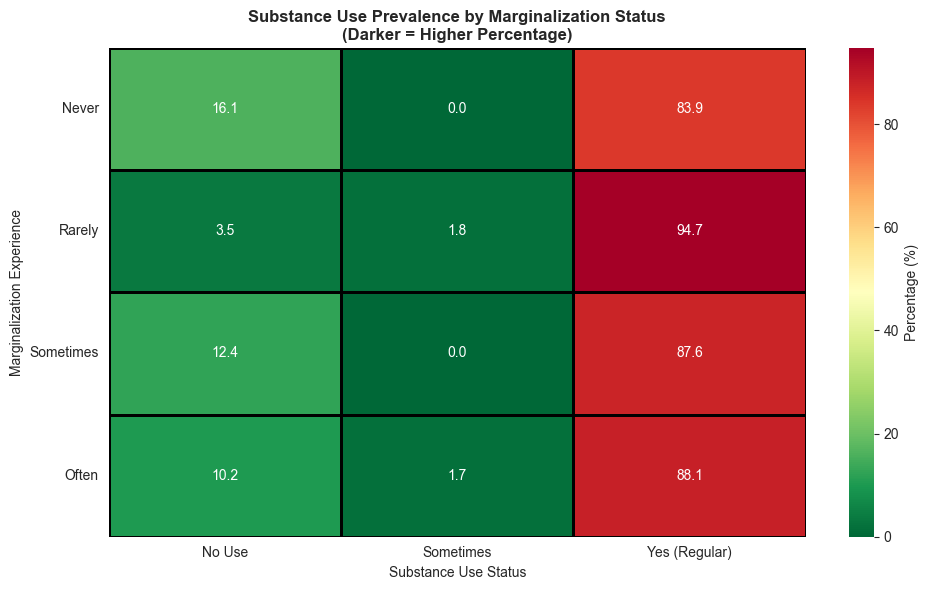

✓ Heatmap saved: visuals/04_marginalization_substance_heatmap.png


In [5]:
# Create a heatmap visualization
fig, ax = plt.subplots(figsize=(10, 6))

# Prepare data for heatmap (percentages)
crosstab_data = pd.crosstab(df[margin_col], df[substance_col])
crosstab_data = crosstab_data.reindex(order, fill_value=0)
crosstab_pct = crosstab_data.div(crosstab_data.sum(axis=1), axis=0) * 100

# Create heatmap
sns.heatmap(crosstab_pct, annot=True, fmt='.1f', cmap='RdYlGn_r', 
            cbar_kws={'label': 'Percentage (%)'}, 
            linewidths=2, linecolor='black', ax=ax)
ax.set_xlabel('Substance Use Status')
ax.set_ylabel('Marginalization Experience')
ax.set_title('Substance Use Prevalence by Marginalization Status\n(Darker = Higher Percentage)', 
             fontweight='bold')
ax.set_xticklabels(['No Use', 'Sometimes', 'Yes (Regular)'])
ax.set_yticklabels(order, rotation=0)

plt.tight_layout()
plt.savefig('../visuals/04_marginalization_substance_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Heatmap saved: visuals/04_marginalization_substance_heatmap.png")

In [6]:
# Key findings summary
print("\n" + "="*60)
print("KEY FINDINGS")
print("="*60)

# Students experiencing marginalization
margin_yes = df[df[margin_col].isin(['Sometimes', 'Often'])]
margin_no = df[df[margin_col].isin(['Never', 'Rarely'])]

margin_yes_substance = (margin_yes[substance_col] != 'No').sum()
margin_no_substance = (margin_no[substance_col] != 'No').sum()

print(f"\n1. MARGINALIZED STUDENTS (Sometimes/Often):")
print(f"   Total: {len(margin_yes)}")
print(f"   With substance involvement: {margin_yes_substance} ({margin_yes_substance/len(margin_yes)*100:.1f}%)")

print(f"\n2. NON-MARGINALIZED STUDENTS (Never/Rarely):")
print(f"   Total: {len(margin_no)}")
print(f"   With substance involvement: {margin_no_substance} ({margin_no_substance/len(margin_no)*100:.1f}%)")

print(f"\n3. RISK RATIO:")
if len(margin_no) > 0:
    rate_marginalized = (margin_yes_substance / len(margin_yes)) if len(margin_yes) > 0 else 0
    rate_not_marginalized = margin_no_substance / len(margin_no)
    risk_ratio = rate_marginalized / rate_not_marginalized if rate_not_marginalized > 0 else 0
    print(f"   Marginalized students are {risk_ratio:.2f}x more likely to report substance use")


KEY FINDINGS

1. MARGINALIZED STUDENTS (Sometimes/Often):
   Total: 196
   With substance involvement: 173 (88.3%)

2. NON-MARGINALIZED STUDENTS (Never/Rarely):
   Total: 170
   With substance involvement: 157 (92.4%)

3. RISK RATIO:
   Marginalized students are 0.96x more likely to report substance use
